## 1. Problema, pesquisa de aplicação e dataset

**Problema.** Prever o consumo de combustível de um automóvel, em **milhas por galão (mpg)**, a partir de características técnicas conhecidas antes de qualquer medição de consumo (peso, potência, ano do modelo etc.). Quanto maior o mpg, mais econômico é o carro.

**Por que é regressão?** O alvo `mpg` é uma **quantidade contínua** (ex.: 18,0; 26,5; 37,3), e não uma categoria. O objetivo é estimar um número, não escolher uma classe.

**Quem usaria e para quê?** Uma montadora ou um planejador de frotas poderia usar a previsão numa fase inicial de projeto/compra, para estimar a eficiência de uma configuração (ex.: carro mais pesado e mais potente) antes de ter o veículo medido em laboratório.

**Aplicação de regressão pesquisada.** Newman, Alimoradian & Lyons (1989) construíram um modelo de regressão para estimar o consumo de combustível de frotas de vans e pequenos caminhões a partir de **cilindrada do motor, massa do veículo e velocidade média**; o termo de massa dominou o modelo, que explicou 77,4% (diesel) e 86,3% (gasolina) da variância. A relação com este trabalho é direta: a mesma lógica (consumo em função de massa e tamanho do motor), aqui em carros de passeio dos anos 1970–1980. Fonte: *Transportation Science*, 23(1), 46–50, DOI 10.1287/trsc.23.1.46.

**Documentação consultada (scikit-learn):** `LinearRegression`, `PolynomialFeatures`, `Pipeline`, `DummyRegressor`, métricas de regressão e a página de armadilhas comuns (vazamento de dados) — links na seção de referências.

**Erro tolerável (definição a priori).** Para uma triagem de projeto, considero útil um erro típico (RMSE) de até cerca de **3 mpg** (aproximadamente 13% do consumo médio do dataset, ~23 mpg). Erros bem maiores trocariam a classificação de um carro "econômico" por "gastão" e levariam a decisões erradas de projeto ou de compra.

### Ficha do dataset

| Campo | Informação |
|---|---|
| Título | Auto-mpg dataset |
| URL no Kaggle | https://www.kaggle.com/datasets/uciml/autompg-dataset |
| Publicador no Kaggle | uciml (UCI Machine Learning) |
| Fonte original | UCI Machine Learning Repository, *Auto MPG* (Quinlan, 1993), revisado a partir da biblioteca StatLib (Carnegie Mellon University) |
| URL da fonte original | https://archive.ics.uci.edu/dataset/9/auto+mpg |
| DOI | https://doi.org/10.24432/C5859H |
| Licença (UCI) | CC BY 4.0 |
| Data de acesso | 05/10/2026 |
| Arquivo utilizado | `auto-mpg.csv` |
| Natureza dos dados | **Reais** (não sintéticos) — consumo em ciclo urbano |

**Linha = um modelo/versão de automóvel** (398 linhas, 9 colunas), com ano de modelo entre 1970 e 1982.

## 2. Configuração das bibliotecas e carregamento dos dados

Usamos `pandas`, `NumPy`, `Matplotlib` e `scikit-learn`. A célula abaixo registra as versões e fixa a semente (`SEED = 42`).

In [1]:
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error   # sklearn >= 1.4
except ImportError:
    root_mean_squared_error = None

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
os.makedirs('figuras', exist_ok=True)

print('Python      :', sys.version.split()[0])
print('NumPy       :', np.__version__)
print('pandas      :', pd.__version__)
print('Matplotlib  :', matplotlib.__version__)
print('scikit-learn:', sklearn.__version__)

Python      : 3.12.3
NumPy       : 2.4.4
pandas      : 3.0.2
Matplotlib  : 3.10.8
scikit-learn: 1.8.0


**Como obter o arquivo (sessão nova do Colab).** A célula tenta, nesta ordem: (1) um `auto-mpg.csv` já presente na pasta atual ou em `/content`; (2) baixar do Kaggle com `kagglehub` (dataset público `uciml/autompg-dataset`, sem token); (3) pedir o upload manual do arquivo. Para o caminho manual: baixe o CSV em https://www.kaggle.com/datasets/uciml/autompg-dataset e envie quando a célula solicitar.

In [2]:
CANDIDATES = ['auto-mpg.csv', '/content/auto-mpg.csv', '/content/drive/MyDrive/auto-mpg.csv']
path = next((p for p in CANDIDATES if os.path.exists(p)), None)

if path is None:
    try:
        import kagglehub
        folder = kagglehub.dataset_download('uciml/autompg-dataset')
        path = os.path.join(folder, 'auto-mpg.csv')
    except Exception as e:
        print('Download automático indisponível:', type(e).__name__)
        from google.colab import files          # só existe no Colab
        up = files.upload()
        path = list(up.keys())[0]

print('Arquivo utilizado:', path)
raw = pd.read_csv(path)
raw.head()

Arquivo utilizado: auto-mpg.csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## 3. Inspeção inicial e regras de limpeza

Registramos dimensões, tipos, ausentes, duplicatas e faixas. Aqui só **inspecionamos** a qualidade; nenhuma estatística aprendida (média, mediana, escala) é calculada para uso em modelos antes da separação.

In [3]:
print('Dimensões (linhas, colunas):', raw.shape)
print('\nTipos:'); print(raw.dtypes)
print('\nAusentes por coluna (NaN):'); print(raw.isna().sum())
print('\nDuplicatas exatas:', raw.duplicated().sum())
print("\nValores '?' por coluna (marcador de ausente usado no arquivo):")
print((raw.astype(str) == '?').sum())

Dimensões (linhas, colunas): (398, 9)

Tipos:
mpg             float64
cylinders         int64
displacement    float64
horsepower          str
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object

Ausentes por coluna (NaN):
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Duplicatas exatas: 0

Valores '?' por coluna (marcador de ausente usado no arquivo):
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


**Achado:** a coluna `horsepower` é lida como texto (`object`) porque contém o marcador `?` em alguns registros: é a forma como o arquivo codifica potência desconhecida. Convertemos `?` em `NaN` (isso é *parsing*, não uma decisão estatística) e **mantemos** essas linhas, pois o alvo está presente; a imputação será feita depois, dentro de um `Pipeline`, ajustada apenas no treino.

In [4]:
df = raw.copy()
df = df.rename(columns={'model year': 'model_year', 'car name': 'car_name'})
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')   # '?' -> NaN

n0 = len(df)
df = df.dropna(subset=['mpg'])                 # regra 1: remover registros sem alvo
n1 = len(df)
df = df.drop_duplicates()                      # regra 2: duplicatas exatas (mesmo carro repetido sem sentido)
n2 = len(df)
df = df.reset_index(drop=True)

print(f'Linhas iniciais: {n0} | sem alvo removidas: {n0-n1} | duplicatas removidas: {n1-n2} | final: {len(df)}')
print('Ausentes em horsepower após conversão:', int(df['horsepower'].isna().sum()))
df.describe().T[['count','min','mean','max']]

Linhas iniciais: 398 | sem alvo removidas: 0 | duplicatas removidas: 0 | final: 398
Ausentes em horsepower após conversão: 6


,count,min,mean,max
mpg,398.0,9.0,23.514573,46.6
cylinders,398.0,3.0,5.454774,8.0
displacement,398.0,68.0,193.425879,455.0
horsepower,392.0,46.0,104.469388,230.0
weight,398.0,1613.0,2970.424623,5140.0
acceleration,398.0,8.0,15.568090,24.8
model_year,398.0,70.0,76.010050,82.0
origin,398.0,1.0,1.572864,3.0


**Regras de limpeza:** (i) remover linhas sem `mpg`; (ii) remover duplicatas exatas, mas só se existirem, pois duplicar uma linha idêntica inflaria artificialmente o conjunto de teste; (iii) **não** remover valores extremos: carros muito econômicos ou muito pesados são reais e fazem parte da população que queremos prever. Nenhuma linha foi excluída para melhorar métrica.

### Definição de variáveis

- **Linha:** um modelo/versão de automóvel. **Alvo:** `mpg` (milhas por galão, ciclo urbano).
- **Preditor principal (simples e polinomial):** `weight`, peso do carro em libras (lb).
- **Candidatos numéricos:** `cylinders` (nº de cilindros), `displacement` (cilindrada, polegadas cúbicas), `horsepower` (potência, hp), `weight` (lb), `acceleration` (segundos de 0 a 60 mph), `model_year` (ano, 70 = 1970).
- **Excluídas:** `car_name` (identificador textual, usado só para identificar registros nas análises finais) e `origin` (código 1/2/3 de região: é categoria, não quantidade; usá-la exigiria *one-hot*, fora do escopo).
- Todas as colunas usadas são **especificações do projeto do carro**, conhecidas antes de medir o consumo, logo não há vazamento do alvo.

In [5]:
TARGET = 'mpg'
MAIN = 'weight'
NUM = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']

X = df[NUM]
y = df[TARGET]
print('X:', X.shape, '| y:', y.shape)

X: (398, 6) | y: (398,)


## 4. Separação treino / validação / teste

Registros independentes (cada linha é um carro distinto, sem ordem temporal relevante para a previsão), então usamos separação aleatória **60/20/20**: primeiro 20% para teste; depois 25% dos 80% restantes (= 20% do total) para validação; `random_state=42` nas duas etapas. Os **mesmos índices** são usados em todos os cenários. A separação ocorre **antes** de qualquer exploração que oriente decisões.

In [6]:
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=SEED)

print(f'Treino    : {len(X_train)} ({len(X_train)/len(X):.1%})')
print(f'Validação : {len(X_val)} ({len(X_val)/len(X):.1%})')
print(f'Teste     : {len(X_test)} ({len(X_test)/len(X):.1%})')
assert len(set(X_train.index) & set(X_val.index)) == 0
assert len(set(X_train.index) & set(X_test.index)) == 0
assert len(set(X_val.index) & set(X_test.index)) == 0
print('\nÍndices disjuntos: OK')
print('Ausentes de horsepower -> treino/val/teste:',
      int(X_train.horsepower.isna().sum()), int(X_val.horsepower.isna().sum()), int(X_test.horsepower.isna().sum()))

Treino    : 238 (59.8%)
Validação : 80 (20.1%)
Teste     : 80 (20.1%)

Índices disjuntos: OK
Ausentes de horsepower -> treino/val/teste: 2 3 1


## 5. Exploração (somente treino)

A partir daqui, qualquer decisão usa **apenas o treino**.

In [7]:
train = X_train.copy(); train[TARGET] = y_train
display(train.describe().T)

,count,mean,std,min,25%,50%,75%,max
cylinders,238.0,5.500000,1.700707,3.0,4.000,4.00,8.000,8.0
displacement,238.0,194.880252,103.586565,68.0,105.000,151.00,293.250,455.0
horsepower,236.0,103.529661,37.732586,46.0,75.000,92.00,129.250,225.0
weight,238.0,2994.428571,845.184274,1649.0,2212.500,2907.50,3612.000,5140.0
acceleration,238.0,15.732773,2.874876,8.0,13.925,15.50,17.775,24.8
model_year,238.0,76.021008,3.550061,70.0,73.000,76.00,79.000,82.0
mpg,238.0,23.260924,7.652899,10.0,17.000,22.15,29.000,44.3


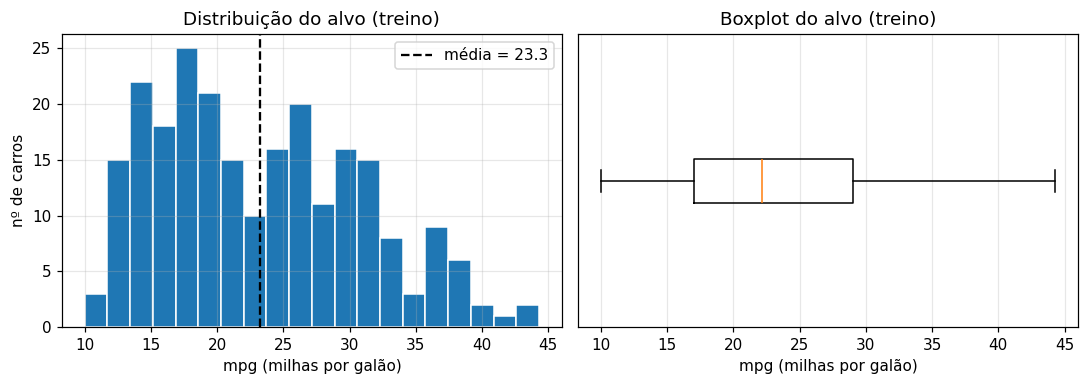

Assimetria do alvo (treino): 0.47
Pontos acima de Q3+1,5·IQR (candidatos a extremos): 0 | abaixo de Q1-1,5·IQR: 0


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].hist(y_train, bins=20, edgecolor='white')
ax[0].axvline(y_train.mean(), color='k', ls='--', label=f'média = {y_train.mean():.1f}')
ax[0].set_xlabel('mpg (milhas por galão)'); ax[0].set_ylabel('nº de carros'); ax[0].set_title('Distribuição do alvo (treino)'); ax[0].legend()
ax[1].boxplot(y_train, vert=False); ax[1].set_xlabel('mpg (milhas por galão)'); ax[1].set_title('Boxplot do alvo (treino)'); ax[1].set_yticks([])
plt.tight_layout(); plt.savefig('figuras/fig1_alvo.png', bbox_inches='tight'); plt.show()

from scipy.stats import skew
print(f'Assimetria do alvo (treino): {skew(y_train):.2f}')
q1, q3 = y_train.quantile([.25, .75]); iqr = q3 - q1
print('Pontos acima de Q3+1,5·IQR (candidatos a extremos):', int((y_train > q3 + 1.5*iqr).sum()),
      '| abaixo de Q1-1,5·IQR:', int((y_train < q1 - 1.5*iqr).sum()))

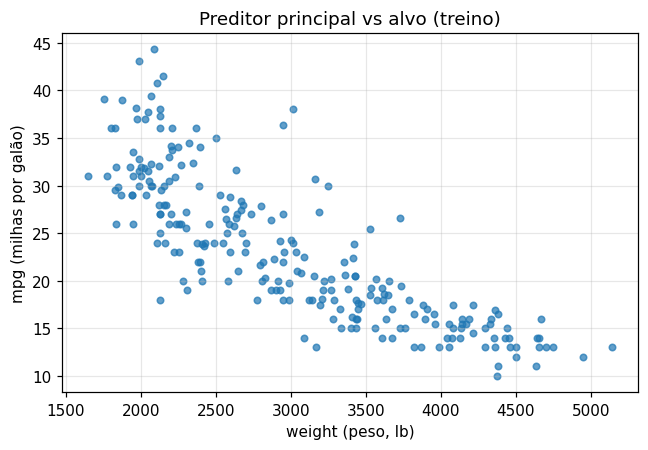

Correlação de Pearson weight x mpg (treino): -0.826


In [9]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(X_train[MAIN], y_train, s=18, alpha=.7)
ax.set_xlabel('weight (peso, lb)'); ax.set_ylabel('mpg (milhas por galão)')
ax.set_title('Preditor principal vs alvo (treino)')
plt.tight_layout(); plt.savefig('figuras/fig2_dispersao.png', bbox_inches='tight'); plt.show()
print('Correlação de Pearson weight x mpg (treino): %.3f' % train[[MAIN, TARGET]].corr().iloc[0, 1])

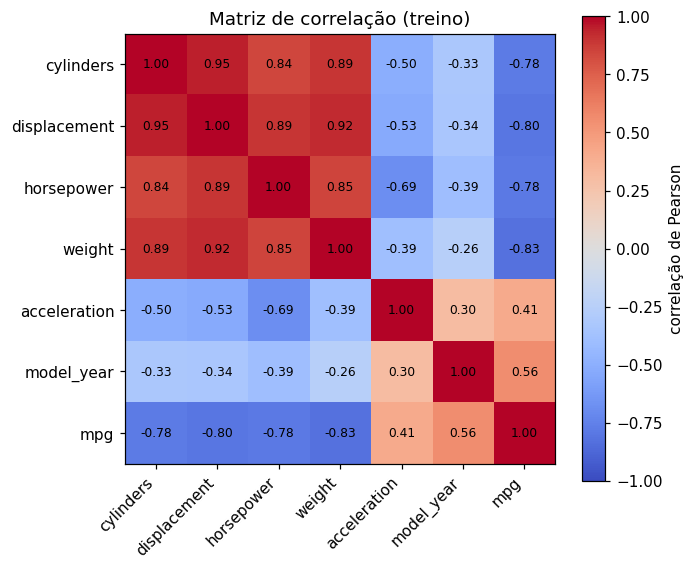

In [10]:
corr = train[NUM + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns); ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='correlação de Pearson'); ax.set_title('Matriz de correlação (treino)')
plt.tight_layout(); plt.savefig('figuras/fig3_correlacao.png', bbox_inches='tight'); plt.show()

### Leitura da exploração e hipóteses (treino)

- **Alvo.** `mpg` no treino: média 23,3; mediana 22,2; desvio-padrão 7,7; mínimo 10,0; máximo 44,3. A distribuição tem **assimetria positiva moderada (0,47)**, concentra-se entre ~17 e ~29 mpg e rareia acima de 35 mpg (**faixa pouco representada**). Nenhum ponto passou das cercas de 1,5·IQR, então não há *outliers* estatísticos a tratar.
- **`weight` × `mpg`.** Relação **decrescente e forte** (r = −0,83). A nuvem sugere uma **curva convexa**: a queda é íngreme até ~3500 lb e se atenua em carros pesados (~12–15 mpg). A dispersão é maior nos carros leves (mpg de 25 a 45 com pesos parecidos).
- **Redundância.** `weight`, `displacement`, `cylinders` e `horsepower` são fortemente correlacionados entre si (r de 0,84 a 0,95; ex.: `displacement`×`cylinders` = 0,95, `weight`×`displacement` = 0,93). `model_year` é pouco correlacionado com os demais (|r| ≤ 0,39) e tem correlação positiva com `mpg` (r = 0,56): informação **nova**.

**Hipóteses a testar:** (H1) uma reta em `weight` captura a tendência principal; (H2) grau 2 reduz o erro sistemático nos carros pesados, mas o ganho deve ser modesto; (H3) `model_year` traz informação que o peso não traz, enquanto `displacement` e `cylinders` apenas repetem o peso (colinearidade) e deixam os coeficientes instáveis; (H4) os carros leves e muito econômicos serão os mais difíceis de prever.

## 6. Pré-processamento, baseline e métricas

**Pré-processamento.** Só `horsepower` tem ausentes. Nos modelos que a usam, `SimpleImputer(strategy='median')` entra **dentro do `Pipeline`**: o `fit` do pipeline aprende a mediana **somente no treino** e o `predict`/`transform` reaplica essa mediana a validação e teste. Assim não há vazamento. A regressão simples e a polinomial usam apenas `weight`, que não tem ausentes.

**Baseline.** `DummyRegressor(strategy="mean")` sempre prevê a média de `mpg` aprendida no treino. É a referência: um modelo só "aprendeu algo útil" se bater esse resultado na validação.

**Métricas.** MAE (erro absoluto médio, em mpg), RMSE (raiz do erro quadrático médio, em mpg, penaliza mais erros grandes) e R² (ganho relativo em comparação a prever a média do conjunto avaliado; pode ser negativo).

In [11]:
def rmse_fn(y_true, y_pred):
    if root_mean_squared_error is not None:
        return root_mean_squared_error(y_true, y_pred)
    return np.sqrt(mean_squared_error(y_true, y_pred))

def metrics(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': rmse_fn(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)}

baseline = DummyRegressor(strategy='mean').fit(X_train[[MAIN]], y_train)
print('Média de mpg aprendida no treino (previsão constante do baseline): %.3f' % baseline.constant_[0, 0])

Média de mpg aprendida no treino (previsão constante do baseline): 23.261


## 7. Regressão linear simples (`weight` → `mpg`)

`LinearRegression().fit(X, y)` **aprende** o intercepto e a inclinação que minimizam a soma dos quadrados dos resíduos (mínimos quadrados); `predict(X)` apenas aplica a reta aprendida a novos dados, sem reajustar nada.

In [12]:
simple = LinearRegression().fit(X_train[[MAIN]], y_train)
b0, b1 = simple.intercept_, simple.coef_[0]
print(f'Intercepto (b0): {b0:.4f} mpg')
print(f'Inclinação (b1): {b1:.6f} mpg por lb  ->  {b1*1000:.2f} mpg a cada +1000 lb')
print(f'Equação: mpg = {b0:.3f} + ({b1:.6f}) * weight')
print(f'Faixa observada de weight no treino: {X_train[MAIN].min():.0f} a {X_train[MAIN].max():.0f} lb (weight = 0 está fora dela)')

Intercepto (b0): 45.6675 mpg
Inclinação (b1): -0.007483 mpg por lb  ->  -7.48 mpg a cada +1000 lb
Equação: mpg = 45.667 + (-0.007483) * weight
Faixa observada de weight no treino: 1649 a 5140 lb (weight = 0 está fora dela)


### Interpretação da regressão simples

- **Equação aprendida (treino):** `mpg = 45,667 − 0,007483 · weight`.
- **Inclinação:** a cada **+1000 lb** de peso, o consumo previsto cai **7,48 mpg**, em média (associação, não causalidade).
- **Intercepto (45,67 mpg):** é o valor da reta em `weight = 0`, que está **fora** da faixa observada (1649–5140 lb); serve para ancorar a reta, não tem significado físico.
- **Desempenho:** na validação, RMSE = 4,90 mpg, MAE = 3,56 mpg e R² = 0,677, contra RMSE = 8,73 mpg e R² = −0,03 do baseline: o RMSE cai ~44%. A reta explica cerca de dois terços da variação, mas deixa um erro típico acima dos 3 mpg que defini como tolerável.
- **Limites:** a reta é rígida. Ela fica **abaixo** dos pontos em carros muito pesados (onde a curva real se achata) e erra mais nos carros leves, onde a dispersão é maior (ver gráfico 1).

## 8. Regressão linear múltipla

A múltipla precisa incluir `weight` e pelo menos mais um preditor. Para decidir **quais atributos** entram, comparamos alguns conjuntos candidatos **pelo RMSE de validação** (o teste continua intocado). Todos usam `SimpleImputer` + `LinearRegression` em `Pipeline`. Critério declarado: menor RMSE de validação; se a diferença for menor que 0,1 mpg, prefere-se o conjunto mais simples e menos colinear.

In [13]:
CANDS = {
    'M1: weight + horsepower': ['weight', 'horsepower'],
    'M2: + model_year': ['weight', 'horsepower', 'model_year'],
    'M3: + acceleration': ['weight', 'horsepower', 'model_year', 'acceleration'],
    'M4: todos os numéricos': NUM,
}

def make_multi():
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('lr', LinearRegression())])

rows = []
for name, cols in CANDS.items():
    mdl = make_multi().fit(X_train[cols], y_train)
    mt = metrics(y_train, mdl.predict(X_train[cols])); mv = metrics(y_val, mdl.predict(X_val[cols]))
    rows.append({'Conjunto': name, 'RMSE treino': mt['RMSE'], 'RMSE validação': mv['RMSE'], 'R² validação': mv['R2']})
cand_df = pd.DataFrame(rows).set_index('Conjunto')
display(cand_df.round(3))

,RMSE treino,RMSE validação,R² validação
Conjunto,,,
M1: weight + horsepower,4.142,4.972,0.667
M2: + model_year,3.329,4.031,0.781
M3: + acceleration,3.329,4.035,0.781
M4: todos os numéricos,3.327,4.042,0.780


**Leitura da tabela de candidatos (só treino e validação):**

- Passar de `weight + horsepower` (M1) para M2 (adicionando `model_year`) reduz o RMSE de validação de **4,97 para 4,03 mpg**: ganho grande.
- Acrescentar `acceleration` (M3) ou também `displacement` e `cylinders` (M4) **não melhora** (4,035 e 4,042, diferença < 0,1 mpg) e aumenta a colinearidade. Pelo critério declarado, escolhe-se o conjunto mais simples: **M2 = `weight`, `horsepower`, `model_year`**.
- Observação: M1 tem RMSE de treino menor que o da simples (4,14 contra 4,30), mas na validação fica **ligeiramente pior** (4,97 contra 4,90). Dado o peso, `horsepower` sozinha acrescenta pouco que generalize. Com apenas 80 registros de validação, essa diferença de 0,07 é pequena demais para ser tratada como conclusiva.

In [14]:
MULTI_NAME = 'M2: + model_year'
MULTI_COLS = CANDS[MULTI_NAME]
multi = make_multi().fit(X_train[MULTI_COLS], y_train)
lr_m = multi.named_steps['lr']
print('Conjunto escolhido:', MULTI_NAME, '->', MULTI_COLS)
print('Mediana de horsepower aprendida no treino (imputação): %.1f hp' % multi.named_steps['imputer'].statistics_[MULTI_COLS.index('horsepower')])
print(f'\nIntercepto: {lr_m.intercept_:.4f} mpg')

Xtr_imp = pd.DataFrame(multi.named_steps['imputer'].transform(X_train[MULTI_COLS]), columns=MULTI_COLS)
coef_tab = pd.DataFrame({'coef (unidade original)': lr_m.coef_,
                         'desvio-padrão no treino': Xtr_imp.std(ddof=0).values})
coef_tab['coef padronizado (mpg por 1 dp)'] = coef_tab['coef (unidade original)'] * coef_tab['desvio-padrão no treino']
coef_tab.index = MULTI_COLS
display(coef_tab.round(5))

# Fator de inflação da variância (VIF): quanto cada preditor é explicável pelos outros
vif = {}
for c in MULTI_COLS:
    others = [k for k in MULTI_COLS if k != c]
    r2c = LinearRegression().fit(Xtr_imp[others], Xtr_imp[c]).score(Xtr_imp[others], Xtr_imp[c])
    vif[c] = 1 / (1 - r2c)
print('\nVIF (treino):', {k: round(v, 2) for k, v in vif.items()})

print('\nCoeficiente de weight: simples = %.6f | múltipla = %.6f' % (b1, lr_m.coef_[MULTI_COLS.index('weight')]))

Conjunto escolhido: M2: + model_year -> ['weight', 'horsepower', 'model_year']
Mediana de horsepower aprendida no treino (imputação): 92.0 hp

Intercepto: -15.1818 mpg


,coef (unidade original),desvio-padrão no treino,coef padronizado (mpg por 1 dp)
weight,-0.00616,843.40681,-5.19847
horsepower,-0.01300,37.50879,-0.48779
model_year,0.76616,3.54259,2.71420



VIF (treino): {'weight': 3.63, 'horsepower': 4.01, 'model_year': 1.21}

Coeficiente de weight: simples = -0.007483 | múltipla = -0.006164


### Interpretação da regressão múltipla (M2, ajustada só no treino)

| Preditor | Coeficiente (unidade original) | Efeito padronizado (mpg por +1 desvio-padrão) | VIF |
|---|---|---|---|
| `weight` | −0,00616 mpg/lb (−6,16 mpg por +1000 lb) | −5,20 | 3,6 |
| `horsepower` | −0,0130 mpg/hp (−1,3 mpg por +100 hp) | −0,49 | 4,0 |
| `model_year` | +0,766 mpg por ano | +2,71 | 1,2 |

Intercepto: −15,18 mpg (sem significado físico: ano 0 e peso 0 estão fora da faixa).

- **Interpretação condicional:** cada coeficiente vale *mantidos os outros constantes*. Ex.: entre carros com mesmo peso e mesma potência, cada ano de modelo mais novo se associa a **+0,77 mpg**. Isso reflete tecnologia e regulação da época, não uma "causa" do ano.
- **Mudança do coeficiente de `weight`:** passou de −7,48 (simples) para −6,16 mpg por 1000 lb (~18% menor em módulo). Na simples, `weight` carregava parte do efeito de `horsepower` e de `model_year` (carros mais pesados eram também mais potentes e mais antigos). É o efeito de variáveis correlacionadas e omitidas.
- **Importância:** os coeficientes em unidade original **não** são comparáveis (lb, hp e anos têm escalas diferentes). Padronizados, `weight` pesa mais (−5,2), depois `model_year` (+2,7); `horsepower` (−0,5) quase some quando o peso já está no modelo, embora tenha r = −0,78 com `mpg` sozinha, por ser redundante com o peso (r = 0,85). Mesmo com VIF < 5, não se deve ler importância só pela magnitude.
- **Desempenho (validação):** RMSE = 4,03 mpg (contra 4,90 da simples), MAE = 3,05 e R² = 0,781.

## 9. Regressão polinomial (graus 2, 3 e 5) sobre `weight`

`PolynomialFeatures(degree=g, include_bias=False)` **transforma** a entrada: de `[x]` gera `[x, x², …, x^g]` (sem coluna de 1, pois o `LinearRegression` já tem intercepto). Ela não aprende nada com `y`. Depois o `LinearRegression` **ajusta** os coeficientes desses novos atributos.

O `Pipeline` encadeia `StandardScaler → PolynomialFeatures → LinearRegression`. O `StandardScaler` (ajustado só no treino) é incluído por **estabilidade numérica**: com `weight` em torno de 3000, `weight⁵` chega a ~10¹⁸ e o grau 5 ficaria mal condicionado. A padronização não muda a família de curvas, só a escala numérica.

In [15]:
def make_poly(degree):
    return Pipeline([('scaler', StandardScaler()),
                     ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                     ('lr', LinearRegression())])

# Demonstração: o que PolynomialFeatures gera no grau 3
demo = make_poly(3).fit(X_train[[MAIN]], y_train)
names = demo.named_steps['poly'].get_feature_names_out(['weight_padronizado'])
print('Atributos gerados no grau 3:', list(names))
amostra = X_train[[MAIN]].head(3)
z = demo.named_steps['scaler'].transform(amostra)
print(pd.DataFrame(demo.named_steps['poly'].transform(z), columns=names, index=amostra.index).assign(weight_original=amostra[MAIN].values).round(3))
print('\nCoeficientes aprendidos (grau 3):', demo.named_steps['lr'].coef_.round(3), '| intercepto: %.3f' % demo.named_steps['lr'].intercept_)

Atributos gerados no grau 3: ['weight_padronizado', 'weight_padronizado^2', 'weight_padronizado^3']
     weight_padronizado  weight_padronizado^2  weight_padronizado^3  \
346              -1.102                 1.214                -1.338   
355              -0.930                 0.865                -0.805   
203              -1.387                 1.923                -2.666   

     weight_original  
346             2065  
355             2210  
203             1825  

Coeficientes aprendidos (grau 3): [-6.944  1.108  0.074] | intercepto: 22.121


In [16]:
DEGREES = [1, 2, 3, 5]            # grau 1 = referência linear simples
poly_models = {d: make_poly(d).fit(X_train[[MAIN]], y_train) for d in DEGREES}

# checagem: grau 1 reproduz a regressão simples
assert np.allclose(poly_models[1].predict(X_val[[MAIN]]), simple.predict(X_val[[MAIN]]))
print('Grau 1 do pipeline == regressão simples: OK')

Grau 1 do pipeline == regressão simples: OK


## 10. Métricas no treino e na validação (modelos ajustados só no treino)

In [17]:
fitted = {
    'Baseline': (baseline, [MAIN]),
    'Simples': (simple, [MAIN]),
    'Múltipla': (multi, MULTI_COLS),
    'Poli grau 2': (poly_models[2], [MAIN]),
    'Poli grau 3': (poly_models[3], [MAIN]),
    'Poli grau 5': (poly_models[5], [MAIN]),
}
rows = []
for name, (mdl, cols) in fitted.items():
    mt = metrics(y_train, mdl.predict(X_train[cols])); mv = metrics(y_val, mdl.predict(X_val[cols]))
    rows.append({'Modelo': name, 'MAE treino': mt['MAE'], 'RMSE treino': mt['RMSE'], 'R² treino': mt['R2'],
                 'MAE validação': mv['MAE'], 'RMSE validação': mv['RMSE'], 'R² validação': mv['R2']})
res_val = pd.DataFrame(rows).set_index('Modelo')
display(res_val.round(3))
print('Unidade de MAE e RMSE: mpg (milhas por galão).')

,MAE treino,RMSE treino,R² treino,MAE validação,RMSE validação,R² validação
Modelo,,,,,,
Baseline,6.476,7.637,0.000,7.235,8.729,-0.026
Simples,3.258,4.300,0.683,3.560,4.900,0.677
Múltipla,2.573,3.329,0.810,3.045,4.031,0.781
Poli grau 2,3.061,4.152,0.704,3.365,4.742,0.697
Poli grau 3,3.061,4.152,0.704,3.370,4.744,0.697
Poli grau 5,3.052,4.144,0.706,3.396,4.765,0.694


Unidade de MAE e RMSE: mpg (milhas por galão).


### Gráfico 1 — Reta e curvas sobre o preditor principal (treino e validação)

As curvas são avaliadas numa **grade ordenada** de `weight` dentro da faixa do treino, para não gerar linhas "serrilhadas".

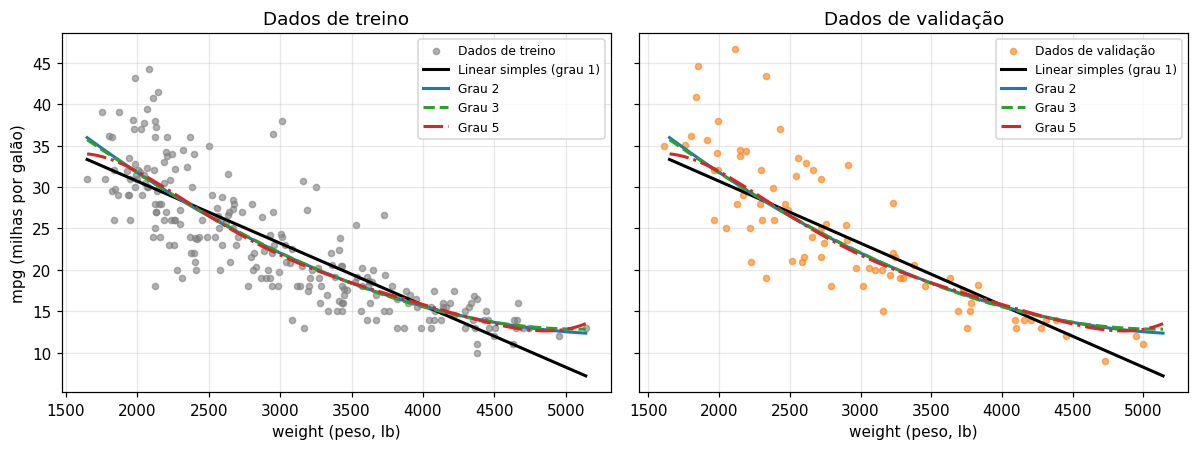

Faixa de weight na validação: 1613 a 4997 lb (treino: 1649 a 5140 lb)


In [18]:
grid = pd.DataFrame({MAIN: np.linspace(X_train[MAIN].min(), X_train[MAIN].max(), 300)})
styles = {1: ('Linear simples (grau 1)', 'k', '-'), 2: ('Grau 2', 'tab:blue', '-'),
          3: ('Grau 3', 'tab:green', '--'), 5: ('Grau 5', 'tab:red', '-.')}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (Xs, ys, titulo, cor) in zip(axes, [(X_train, y_train, 'Dados de treino', 'tab:gray'),
                                            (X_val, y_val, 'Dados de validação', 'tab:orange')]):
    ax.scatter(Xs[MAIN], ys, s=16, alpha=.6, color=cor, label=titulo)
    for d, (lab, c, ls) in styles.items():
        ax.plot(grid[MAIN], poly_models[d].predict(grid), color=c, ls=ls, lw=2, label=lab)
    ax.set_xlabel('weight (peso, lb)'); ax.set_title(titulo); ax.legend(fontsize=8)
axes[0].set_ylabel('mpg (milhas por galão)')
plt.tight_layout(); plt.savefig('figuras/fig4_curvas.png', bbox_inches='tight'); plt.show()
print('Faixa de weight na validação: %d a %d lb (treino: %d a %d lb)' % (X_val[MAIN].min(), X_val[MAIN].max(), X_train[MAIN].min(), X_train[MAIN].max()))

### Gráfico 2 — RMSE de treino e de validação em função do grau (antes do reajuste final)

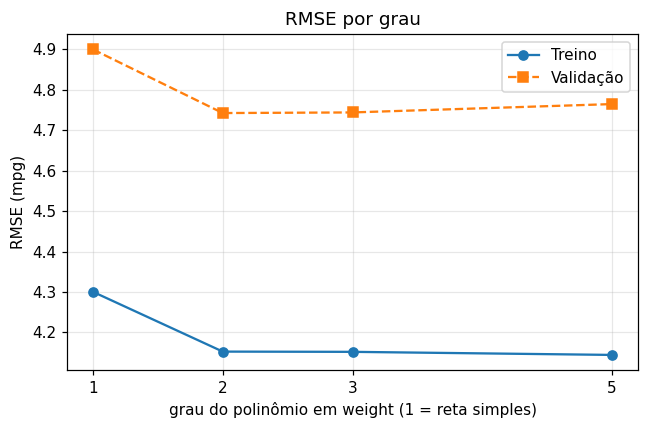

 grau  RMSE treino  RMSE validação
    1        4.300           4.900
    2        4.152           4.742
    3        4.152           4.744
    5        4.144           4.765


In [19]:
rm_tr = [rmse_fn(y_train, poly_models[d].predict(X_train[[MAIN]])) for d in DEGREES]
rm_va = [rmse_fn(y_val, poly_models[d].predict(X_val[[MAIN]])) for d in DEGREES]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(DEGREES, rm_tr, 'o-', label='Treino'); ax.plot(DEGREES, rm_va, 's--', label='Validação')
ax.set_xticks(DEGREES); ax.set_xlabel('grau do polinômio em weight (1 = reta simples)'); ax.set_ylabel('RMSE (mpg)')
ax.set_title('RMSE por grau'); ax.legend()
plt.tight_layout(); plt.savefig('figuras/fig5_rmse_grau.png', bbox_inches='tight'); plt.show()
print(pd.DataFrame({'grau': DEGREES, 'RMSE treino': np.round(rm_tr, 3), 'RMSE validação': np.round(rm_va, 3)}).to_string(index=False))

### Interpretação da regressão polinomial

- **O que `PolynomialFeatures` faz:** para grau 3, cada `weight` (padronizado) vira três colunas, `x`, `x²` e `x³` (ver a célula de demonstração acima). É só uma **transformação** da entrada, sem uso de `y`. O ajuste dos coeficientes é feito depois pelo `LinearRegression`.
- **Curvo na entrada, linear nos coeficientes:** `mpg = b0 + b1·x + b2·x² + b3·x³` é uma curva em `x`, mas é uma **soma ponderada** de atributos fixos (`x`, `x²`, `x³`), logo os mínimos quadrados continuam resolvendo um problema linear nos `b`.
- **Curvas (gráfico 1):** as curvas de graus 2, 3 e 5 são praticamente **sobrepostas** na faixa com muitos dados: descem até ~3500 lb e se achatam em 12–15 mpg, como sugeria a nuvem. A diferença aparece só na ponta pesada (> 4800 lb), onde o **grau 5 sobe levemente**, um comportamento implausível (carro mais pesado não ficaria mais econômico) e típico da instabilidade de polinômios de grau alto nas bordas, onde há poucos dados.
- **Treino × validação:** RMSE de treino 4,152 (grau 2), 4,152 (grau 3) e 4,144 (grau 5); de validação 4,742, 4,744 e 4,765. O **menor RMSE de validação é do grau 2**, mas a diferença entre graus é de centésimos de mpg. A melhora de treino a partir do grau 2 é quase nula, e a de validação **não acompanha** (o grau 5 já piora um pouco).
- **Sub/sobreajuste:** a **reta (grau 1)** está levemente subajustada (RMSE 4,30/4,90, pior que o grau 2 nos dois conjuntos), por não captar a curvatura. **Não há evidência clara de sobreajuste**: a distância treino→validação é de ~0,6 mpg em todos os graus (0,60, 0,59, 0,59 e 0,62), inclusive no baseline (7,64 → 8,73), o que indica que o conjunto de validação é simplesmente mais disperso, e não que o grau alto memorizou o treino.

## 11. Escolha por validação (decisão fechada **antes** de abrir o teste)

O grau é escolhido entre **2, 3 e 5** pelo menor RMSE de validação (o grau 1 é a regressão simples). A recomendação de cenário considera validação, interpretabilidade e custo do erro.

In [20]:
cand_deg = {d: rm_va[DEGREES.index(d)] for d in (2, 3, 5)}
BEST_DEG = min(cand_deg, key=cand_deg.get)
print('RMSE de validação por grau:', {d: round(v, 3) for d, v in cand_deg.items()})
print('Grau escolhido:', BEST_DEG)
print('\nRMSE de validação por cenário:')
print(res_val['RMSE validação'].round(3).to_string())

RMSE de validação por grau: {2: 4.742, 3: 4.744, 5: 4.765}
Grau escolhido: 2

RMSE de validação por cenário:
Modelo
Baseline       8.729
Simples        4.900
Múltipla       4.031
Poli grau 2    4.742
Poli grau 3    4.744
Poli grau 5    4.765


### Decisões fechadas antes do teste

- **Grau escolhido: 2** (menor RMSE de validação: 4,742 mpg; grau 3 = 4,744; grau 5 = 4,765). A diferença para o grau 3 é desprezível, e o grau 2 é o mais simples e estável. Ganho sobre a reta: ~3% de RMSE, modesto.
- **Preditores da múltipla:** M2 = `weight`, `horsepower`, `model_year`.
- **Cenário recomendado: regressão linear múltipla (M2).** Tem o menor RMSE de validação (4,03 mpg, contra 4,74 do polinomial de grau 2 e 4,90 da simples), é facilmente interpretável (coeficientes em mpg por lb, hp e ano) e usa só três atributos. Quando a diferença é pequena (ex.: grau 2 contra reta), prefiro o modelo mais simples; aqui a diferença do M2 é grande, então a complexidade extra de uma variável se justifica.
- **Custo do erro:** mesmo o melhor modelo tem RMSE de validação (4,0 mpg) acima da tolerância de ~3 mpg definida no início. Serve para **triagem** (ordenar carros econômicos e gastões), não para especificar consumo com precisão.

## 12. Reajuste final (treino + validação) e avaliação única no teste

Com todas as escolhas fechadas (preditores da múltipla e grau), reajustamos os quatro modelos em **treino + validação** e avaliamos no **teste uma única vez**. O baseline passa a usar a média de `mpg` de treino + validação (nunca a do teste).

In [21]:
X_tv = pd.concat([X_train, X_val]); y_tv = pd.concat([y_train, y_val])

final = {
    'Baseline': (DummyRegressor(strategy='mean'), [MAIN]),
    'Linear simples': (LinearRegression(), [MAIN]),
    'Linear múltipla': (make_multi(), MULTI_COLS),
    f'Polinomial grau {BEST_DEG}': (make_poly(BEST_DEG), [MAIN]),
}
preds_test, rows = {}, []
for name, (mdl, cols) in final.items():
    mdl.fit(X_tv[cols], y_tv)
    p = mdl.predict(X_test[cols]); preds_test[name] = p
    r = metrics(y_test, p); rows.append({'Modelo final': name, 'MAE teste': r['MAE'], 'RMSE teste': r['RMSE'], 'R² teste': r['R2']})
res_test = pd.DataFrame(rows).set_index('Modelo final')
display(res_test.round(3))
print('Média de mpg usada pelo baseline final (treino+validação): %.3f' % final['Baseline'][0].constant_[0, 0])
print('Média de mpg do teste (apenas para comparação, NÃO usada): %.3f' % y_test.mean())

,MAE teste,RMSE teste,R² teste
Modelo final,,,
Baseline,5.955,7.347,-0.004
Linear simples,3.118,3.859,0.723
Linear múltipla,2.453,3.073,0.824
Polinomial grau 2,2.799,3.626,0.755


Média de mpg usada pelo baseline final (treino+validação): 23.608
Média de mpg do teste (apenas para comparação, NÃO usada): 23.143


### Gráfico 3 — Valores reais vs previstos (teste, quatro modelos finais)

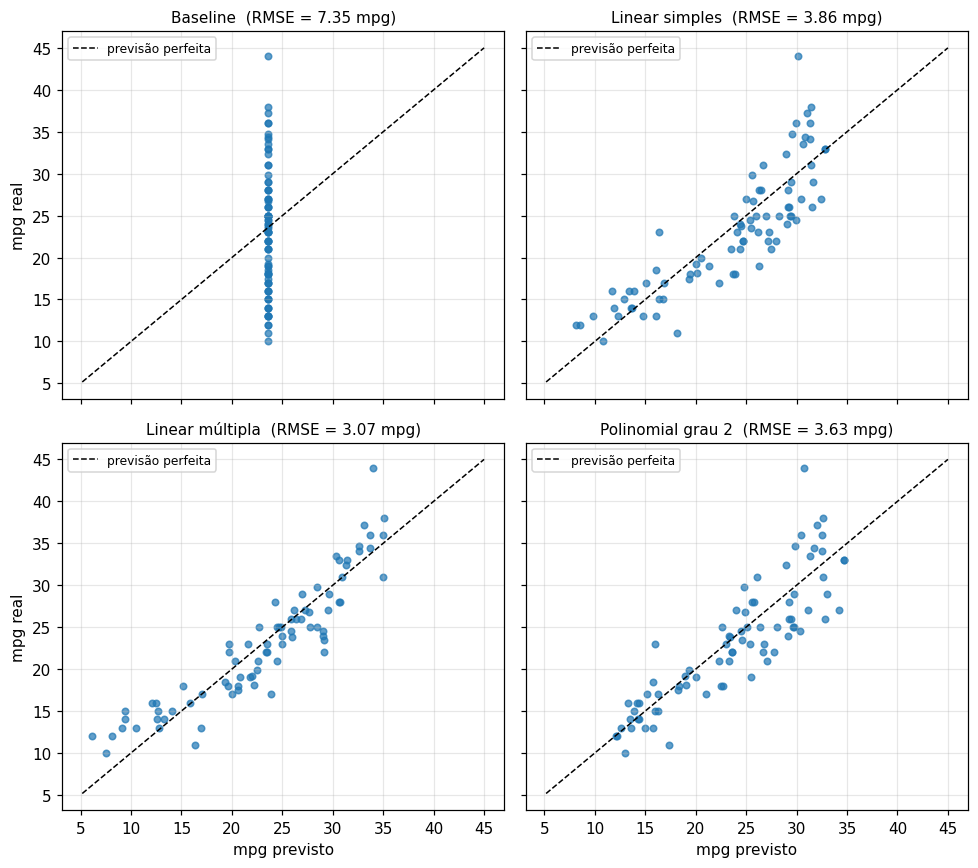

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
lo, hi = min(y_test.min(), min(p.min() for p in preds_test.values())) - 1, max(y_test.max(), max(p.max() for p in preds_test.values())) + 1
for ax, (name, p) in zip(axes.ravel(), preds_test.items()):
    ax.scatter(p, y_test, s=18, alpha=.7)
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='previsão perfeita')
    ax.set_title(f"{name}  (RMSE = {res_test.loc[name, 'RMSE teste']:.2f} mpg)", fontsize=10); ax.legend(fontsize=8)
for ax in axes[1]: ax.set_xlabel('mpg previsto')
for ax in axes[:, 0]: ax.set_ylabel('mpg real')
plt.tight_layout(); plt.savefig('figuras/fig6_real_previsto.png', bbox_inches='tight'); plt.show()

### Gráfico 4 — Resíduos vs valores previstos (resíduo = real − previsto)

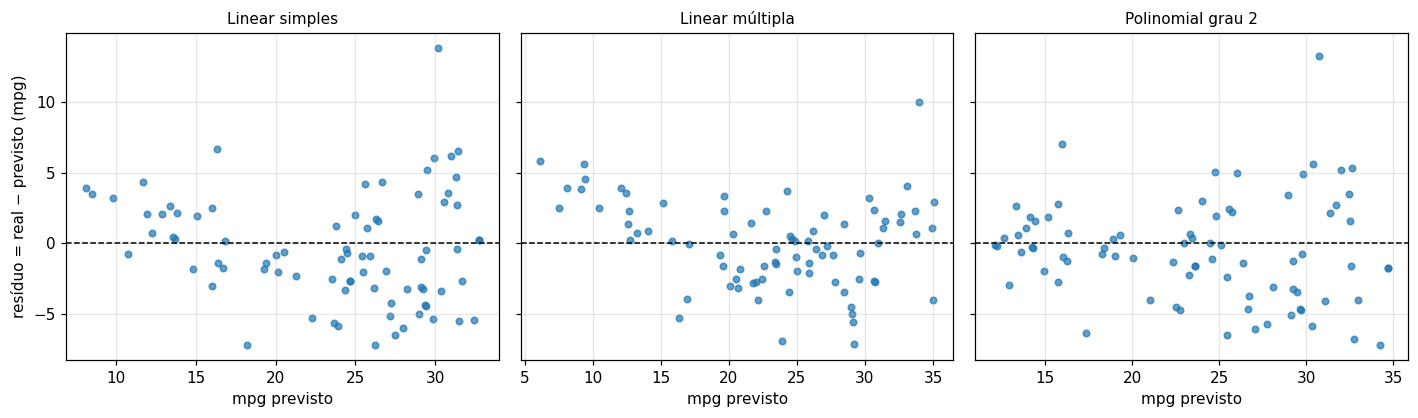

Linear simples           média do resíduo = -0.41 | desvio = 3.84 | min = -7.2 | max = +13.8
Linear múltipla          média do resíduo = -0.03 | desvio = 3.07 | min = -7.2 | max = +10.0
Polinomial grau 2        média do resíduo = -0.50 | desvio = 3.59 | min = -7.2 | max = +13.3


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9), sharey=True)
for ax, name in zip(axes, ['Linear simples', 'Linear múltipla', f'Polinomial grau {BEST_DEG}']):
    p = preds_test[name]; resid = y_test.values - p
    ax.scatter(p, resid, s=18, alpha=.7); ax.axhline(0, color='k', ls='--', lw=1)
    ax.set_title(name, fontsize=10); ax.set_xlabel('mpg previsto')
axes[0].set_ylabel('resíduo = real − previsto (mpg)')
plt.tight_layout(); plt.savefig('figuras/fig7_residuos.png', bbox_inches='tight'); plt.show()
for name in ['Linear simples', 'Linear múltipla', f'Polinomial grau {BEST_DEG}']:
    r = y_test.values - preds_test[name]
    print(f'{name:24s} média do resíduo = {r.mean():+.2f} | desvio = {r.std():.2f} | min = {r.min():+.1f} | max = {r.max():+.1f}')

## 13. Diagnóstico: onde o modelo erra mais?

In [24]:
REC = 'Linear múltipla'      # modelo recomendado na validação (decisão da seção 11)
diag = df.loc[X_test.index, ['car_name', 'weight', 'horsepower', 'model_year', 'mpg']].copy()
diag['previsto'] = preds_test[REC]; diag['residuo'] = diag['mpg'] - diag['previsto']; diag['|residuo|'] = diag['residuo'].abs()
print('Modelo analisado:', REC)
display(diag.sort_values('|residuo|', ascending=False).head(6).round(2))

# razão RMSE/MAE por modelo: quanto mais acima de ~1,25, mais os erros grandes pesam
print((res_test['RMSE teste'] / res_test['MAE teste']).round(2).rename('RMSE/MAE'))

# dois registros para interpretar: o de maior erro e um de erro típico (mediano)
i_max = diag['|residuo|'].idxmax()
i_med = (diag['|residuo|'] - diag['|residuo|'].median()).abs().idxmin()
exemplos = diag.loc[[i_max, i_med]].round(2)
display(exemplos)

Modelo analisado: Linear múltipla


,car_name,weight,horsepower,model_year,mpg,previsto,residuo,|residuo|
394,vw pickup,2130,52.0,82,44.0,34.00,10.00,10.00
389,ford granada l,2835,112.0,82,22.0,29.16,-7.16,7.16
275,volvo 264gl,3140,125.0,78,17.0,23.92,-6.92,6.92
42,dodge monaco (sw),4955,180.0,71,12.0,6.16,5.84,5.84
5,ford galaxie 500,4341,198.0,70,15.0,9.40,5.60,5.60
341,chevrolet citation,2725,110.0,81,23.5,29.10,-5.60,5.60


Modelo final
Baseline             1.23
Linear simples       1.24
Linear múltipla      1.25
Polinomial grau 2    1.30
Name: RMSE/MAE, dtype: float64


,car_name,weight,horsepower,model_year,mpg,previsto,residuo,|residuo|
394,vw pickup,2130,52.0,82,44.0,34.00,10.00,10.00
15,plymouth duster,2833,95.0,70,22.0,19.68,2.32,2.32


### Diagnóstico com referência aos gráficos 3 e 4 e às tabelas acima

1. **A recomendação se sustentou.** No teste, a **múltipla** teve o menor erro (RMSE 3,07 mpg; MAE 2,45; R² 0,82), seguida do **polinomial grau 2** (3,63; 2,80; 0,76) e da **simples** (3,86; 3,12; 0,72). Todos superam bem o baseline (RMSE 7,35; R² ≈ 0): redução de RMSE de ~58% (múltipla), ~51% (grau 2) e ~47% (simples). **Resultado inesperado:** os erros no teste foram **menores** que na validação (ex.: múltipla 3,07 contra 4,03). A explicação mais plausível é que o conjunto de validação era mais difícil/disperso (RMSE do baseline 8,73 contra 7,35 no teste) e que o reajuste usou 25% mais dados; com 80 registros por conjunto, a variação entre amostras é grande. As escolhas **não** foram alteradas.
2. **MAE e RMSE levam à mesma ordem.** A razão RMSE/MAE fica entre 1,23 e 1,30, indicando uma cauda moderada de erros grandes. Os maiores erros da múltipla são `vw pickup` (+10,0 mpg), `ford granada l` (−7,2) e `volvo 264gl` (−6,9).
3. **Reais × previstos (gráfico 3).** Os pontos acompanham a diagonal, mas se espalham mais para **carros com mpg alto** (> 30), onde os modelos tendem a **subestimar**. Nos carros pesados, os modelos lineares podem prever valores **abaixo do mínimo observado** (ex.: `dodge monaco (sw)`, previsão 6,2 mpg, enquanto o menor valor do dataset é 9 mpg): previsão pouco plausível.
4. **Resíduos (gráfico 4).** Na **simples** há padrão em **curva** (resíduos positivos nos extremos de peso, negativos no meio), sinal da não linearidade que a reta não capta, e um ponto extremo (+13,8). Na **múltipla** os resíduos ficam mais centrados em zero (média ≈ 0), com leve **funil** (maior dispersão nas previsões altas) e um ponto extremo (+10,0). No **polinomial** a curva foi atenuada, mas o funil e o ponto extremo (+13,3) permanecem: a variância do erro **não é constante** (carros econômicos são mais imprevisíveis), o que a regressão linear com atributos desta base não resolve.
5. **Dois registros do teste (modelo múltipla):** `vw pickup` (real 44,0; previsto 34,0; resíduo +10,0): carro leve (2130 lb), de baixa potência (52 hp) e de 1982, no extremo da faixa de eficiência onde há pouquíssimos dados; o dataset não traz tipo de combustível nem de carroceria, e essas características podem explicar a eficiência incomum. `plymouth duster` (real 22,0; previsto 19,7; resíduo +2,3): erro típico (abaixo do MAE de 2,45), em carro de peso e potência medianos.

In [25]:
results = {
    'versions': {'python': sys.version.split()[0], 'numpy': np.__version__, 'pandas': pd.__version__,
                 'matplotlib': matplotlib.__version__, 'sklearn': sklearn.__version__},
    'n': {'total': len(df), 'train': len(X_train), 'val': len(X_val), 'test': len(X_test)},
    'raw_shape': list(raw.shape),
    'baseline_mean_train': float(baseline.constant_[0, 0]),
    'simple': {'b0': float(b0), 'b1': float(b1)},
    'multi': {'name': MULTI_NAME, 'cols': MULTI_COLS, 'intercept': float(lr_m.intercept_),
              'coef': dict(zip(MULTI_COLS, map(float, lr_m.coef_))),
              'coef_std': dict(zip(MULTI_COLS, map(float, coef_tab['coef padronizado (mpg por 1 dp)']))),
              'vif': {k: float(v) for k, v in vif.items()}},
    'cands': cand_df.reset_index().to_dict(orient='records'),
    'val_table': res_val.reset_index().to_dict(orient='records'),
    'deg_rmse': {'degrees': DEGREES, 'train': rm_tr, 'val': rm_va},
    'best_deg': int(BEST_DEG),
    'test_table': res_test.reset_index().to_dict(orient='records'),
    'test_baseline_mean_used': float(final['Baseline'][0].constant_[0, 0]),
    'test_mean': float(y_test.mean()),
    'rec': REC,
    'examples': exemplos.reset_index().to_dict(orient='records'),
    'top_err': diag.sort_values('|residuo|', ascending=False).head(6).reset_index().to_dict(orient='records'),
    'corr': corr.round(3).to_dict(),
    'target_skew': float(skew(y_train)),
    'target_desc': y_train.describe().to_dict(),
}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=1, default=float)
print('results.json salvo.')

results.json salvo.


## 14. Conclusões e limitações

- **Uma variável, mais variáveis, mais grau.** Só `weight` já reduz o RMSE de validação de 8,73 (baseline) para 4,90 mpg. Aumentar o grau trouxe pouco: o grau 2 baixou o RMSE para 4,74 e graus 3 e 5 não melhoraram. **Adicionar informação nova** (`model_year`) valeu muito mais que adicionar flexibilidade: 4,03 mpg. No teste: baseline 7,35; simples 3,86; polinomial grau 2: 3,63; múltipla 3,07 mpg.
- **Utilidade prática.** Com RMSE de teste ≈ 3,1 mpg o modelo recomendado é útil para **triagem** de eficiência (limite que fixei ≈ 3 mpg), mas, na validação, o erro (4,0) o ultrapassava; a conclusão depende do conjunto, o que mostra a incerteza de avaliar com 80 registros.
- **Limitações.** (i) Amostra pequena (398 carros; 80 por conjunto de avaliação) e uma única separação aleatória. (ii) Dados de 1970–1982, ciclo urbano, carros de outra época tecnológica. (iii) Mesmo modelo de carro aparece em anos diferentes, então as linhas **não são totalmente independentes**, o que pode favorecer um pouco as métricas. (iv) Variáveis ausentes (aerodinâmica, transmissão, tipo de combustível/carroceria). (v) Colinearidade entre `weight`, `horsepower` e cilindrada limita a interpretação individual dos coeficientes. (vi) Erro com variância não constante (funil).
- **Onde não confiar.** Carros muito leves/econômicos (> 35 mpg, poucos dados), carros muito pesados (previsões podem sair abaixo do mínimo observado) e **qualquer carro moderno** (híbridos, elétricos, motores turbo): extrapolar além da faixa observada (1613–5140 lb; 1970–1982) é arriscado, sobretudo com polinômios de grau alto.
- **Próximos experimentos (sem alterar esta avaliação final).** Validação cruzada para estimar a incerteza; incluir `origin` por *one-hot*; modelar `log(mpg)` ou o consumo em galões por milha (1/mpg), que linearizam melhor a relação com o peso e podem reduzir o funil; testar Ridge/Lasso para lidar com colinearidade.

## 15. Referências

- QUINLAN, R. **Auto MPG** [dataset]. UCI Machine Learning Repository, 1993. DOI: https://doi.org/10.24432/C5859H. https://archive.ics.uci.edu/dataset/9/auto+mpg (licença CC BY 4.0). Acesso em 05/10/2026.
- UCI ML (publicador). **Auto-mpg dataset**. Kaggle. https://www.kaggle.com/datasets/uciml/autompg-dataset. Acesso em 05/10/2026.
- NEWMAN, P. W. G.; ALIMORADIAN, B.; LYONS, T. J. Estimating Fleet Fuel Consumption for Vans and Small Trucks. **Transportation Science**, v. 23, n. 1, p. 46–50, 1989. https://doi.org/10.1287/trsc.23.1.46.
- scikit-learn. LinearRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- scikit-learn. PolynomialFeatures: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
- scikit-learn. DummyRegressor: https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html
- scikit-learn. Regression metrics: https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
- scikit-learn. Common pitfalls (data leakage): https://scikit-learn.org/stable/common_pitfalls.html
- Atividade prática de regressão, Aprendizado de Máquina — Unidade 2 (enunciado do professor).

**Código adaptado:** a estrutura geral (Pipeline, `train_test_split`, métricas) segue exemplos da documentação do scikit-learn; o restante foi escrito para este estudo. O cálculo de VIF foi implementado à mão (regressão de cada preditor sobre os demais).